# Adversarial Attack


На лекции мы разобрались, что ML-модели можно атаковать. Например, в задаче распознавания лиц мы можем добавить к изображению небольшой шум, который заставит модель совершить ошибку.

В этом задании мы научимся защищать модель от атак. Для иллюстрации мы будем использовать простую логистическую регрессию, но похожие идеи можно применить и к сложным нейросетям.

В качестве задачи рассмотрим классификацию изображений MNIST для цифр 0 и 1.

### Подготовка

In [ ]:
# Загрузим библиотеки, которые нам пригодятся

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split

import numpy as np
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore")

In [ ]:
# Загрузим датасет
mnist = fetch_openml('mnist_784', as_frame=False, cache=True)

# подготовим данные в нужном формате
X = mnist.data.astype('float32')
y = mnist.target.astype('int64')

# Оставим в датасете только классы 0 и 1
y_bin = y[(y == 0) | (y == 1)]
X_bin = X[(y == 0) | (y == 1)]


# Для удобства, обозначим лейблы классов за -1 (обозначает цифру 0)
# и 1 (обозначает цифру 1)
y_bin[y_bin == 0] = -1

# Посмотрим на долю единиц в датасете
positive_class_size = len(y_bin[y_bin == 1])
positive_class_rate = positive_class_size / len(y_bin)

print("Доля единиц в датасете: ", positive_class_rate)

Доля единиц в датасете:  0.5329499323410013


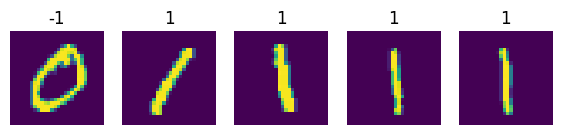

In [ ]:
# Посмотрим на первые 5 примеров

n = 5

fig, axs = plt.subplots(1, n, figsize=(7, 3))

for ax, image, label in zip(axs, X_bin[:n], y_bin[:n]):

  # Переводим картинку из вектора длины 784 в матрицу 28 x 28
  image_reshaped = image.reshape(28, 28)

  ax.imshow(image_reshaped)
  ax.set_title(label)
  ax.axis("off")

### Шаг 1. Тренировка незащищенной модели [2 балла]


Начнем с того, что натренируем стандартную модель логистической регрессии и оценим ее устойчивость к атакам. Из курса ML вспомним, что логистическая регрессия это линейная модель:

$$h_\theta(x) = w^T x + b$$

с функцией ошибки

\begin{equation}
\ell(h_\theta(x), y) = \log(1+\exp(-y\cdot h_\theta(x))) \equiv L(y \cdot h_\theta(x))
\end{equation}

Здесь для сокращения записи мы ввели функцию $L(x) = \log(1+\exp(-x))$.


**Что нужно сделать:**

1. Разбить данные на train и test

2. Нормализовать датасет ($X$) так, чтобы значения каждого пикселя были в диапазоне [0, 1]

3. Натренировать модель логистической регрессии на train set

4. Оценить точность (accuracy) логистической регрессии на test set

Для решения этой части задания можно использовать встроенные методы `sklearn`



In [ ]:
# Для решения могут пригодиться следующие методы

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score

X_train, X_test, y_train, y_test = train_test_split(
    X_bin, y_bin,
    test_size=0.25,
    random_state=42,
    stratify=y_bin
)

scaler = MinMaxScaler(feature_range=(0.0, 1.0))
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

model = LogisticRegression(
    penalty="l2",
    solver="lbfgs",
    max_iter=2000,
    n_jobs=-1
)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f"Test accuracy: {acc:.4f}")

Test accuracy: 0.9986


### Шаг 2. Атака незащищенной модели [3 балла]

Будем считать, что мы можем атаковать модель, изменив значение каждого пикселя в изображении не более чем на 0.2 (атака производится после нормализации):

$$x' = x + \delta, \quad ||\delta||_{\infty} \le 0.2 = ɛ.$$

Как мы доказали на лекции, в случае логистической регрессии мы можем найти точное выражение для оптимальной атаки:
\begin{equation}
\delta^\star = - y \cdot \epsilon \cdot \mathrm{sign}(w),
\end{equation}
где $w$ это вектор весов модели, который мы получили на Шаге 1.

Давайте проведем атаку на модель и посмотрим как сильно упадет её точность.

**Что нужно сделать**

1. Вычислить значения оптимальной атаки $\delta^\star$ для каждого класса (-1 и 1)

2. Применить атаку к каждому изображению в test set

3. Оценить точность (accuracy) логистической регрессии на атакованном test set

Обратите внимание, что атака изображения может вывести значения пикселей из диапазона $[0, 1]$. Для простоты в этом задании можно не делать повторной нормализации.

Для решения этой части задания можно использовать встроенные методы `sklearn`

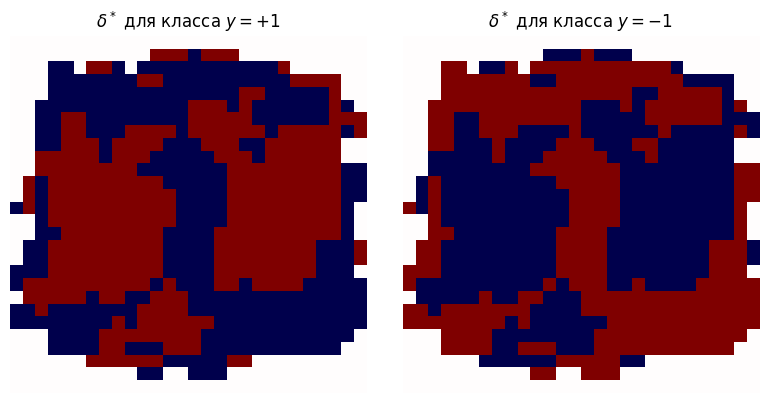

In [ ]:
# TODO: Вычислите значения оптимальной атаки на картинки каждого класса и
# изобразите их

# Вектор весов модели можно получить следующим образом:
# weight = model.coef_

# Your code here

eps = 0.2

w = model.coef_.ravel()

sgn_w = np.sign(w)
delta_y_pos = -(+1) * eps * sgn_w
delta_y_neg = -(-1) * eps * sgn_w

delta_pos_img = delta_y_pos.reshape(28, 28)
delta_neg_img = delta_y_neg.reshape(28, 28)

X_test_adv = X_test + (-y_test.reshape(-1, 1)) * eps * sgn_w.reshape(1, -1)


fig, ax = plt.subplots(1, 2, figsize=(8, 4))
ax[0].imshow(delta_pos_img, cmap="seismic", vmin=-eps, vmax=eps)
ax[0].set_title(r"$\delta^*$ для класса $y=+1$")
ax[0].axis("off")

ax[1].imshow(delta_neg_img, cmap="seismic", vmin=-eps, vmax=eps)
ax[1].set_title(r"$\delta^*$ для класса $y=-1$")
ax[1].axis("off")

plt.tight_layout()
plt.show()


Картинки ожидаемо получились противположными. Для класса +1 атака двгает изображение в сторону уменьшения логита, для класса -1 в противоположную сторону.

In [ ]:
# TODO: Примените атаку к изображениям в test set и посчитайте точность модели

# Your code here

y_pred_adv = model.predict(X_test_adv)
acc_adv = accuracy_score(y_test, y_pred_adv)

print(f"Test accuracy (adversarial, eps={eps}): {acc_adv:.4f}")

Test accuracy (adversarial, eps=0.2): 0.1223


Точность уменьшилась значительно, в несколько раз.

### Шаг 3. Тренировка Robust Classifier [5 баллов]

Чтобы натренировать модель, устойчивую к атакам, нужно изменить процесс тренировки. Во время тренировки нам нужно минимизировать не стандартную функцию ошибки логистической регрессии, а модифицированную:

\begin{equation}
\DeclareMathOperator*{\minimize}{minimize}
\minimize_{w,b} \frac{1}{D}\sum_{(x,y) \in D} L \left(y \cdot (w^Tx + b) - \epsilon \|w\|_1 \right ).
\end{equation}

Натренируйте модель Robust Logistic Regression на train set и оцените ее устойчивость к атакам.

**Что нужно сделать:**

1. Реализуйте свой ML-метод: класс **RobustLogisticRegression**, который наследует от sklearn класса [BaseEstimator](https://scikit-learn.org/stable/modules/generated/sklearn.base.BaseEstimator.html). Новый класс должен содержать методы `fit` и `predict`, а внутри метода `fit` должна проходить процедура градиентного спуска с новой функцией ошибки. Шаблон класса дан ниже.

2. Натренируйте Robust Logistic Regression и оцените ее точность на чистом test set

3. Вычислите атаку $\delta^\star = - y \cdot \epsilon \cdot \mathrm{sign}(w)$ на модель и проатакуйте test set. Для атаки используйте веса робастной модели

4. Оцените точность модели на атакованном test set

Для решения этой части задания **нельзя** использовать встроенные методы `sklearn`, только шаблон ниже и методы `numpy`

In [ ]:
from sklearn.base import BaseEstimator

# TODO: Write RobustLogisticRegression class

class RobustLogisticRegression(BaseEstimator):

    def __init__(self, eps=0.2, lr=0.1, n_iter=2000):
        self.eps = float(eps)
        self.lr = float(lr)
        self.n_iter = int(n_iter)
        self.w = None
        self.b = 0.0

    def fit(self, X, y):
        """Метод для тренировки модели по тренировочным данным X и y"""
        X = np.asarray(X, dtype=float)
        y = np.asarray(y, dtype=float).reshape(-1)
        n, d = X.shape

        self.w = np.zeros(d, dtype=float)
        self.b = 0.0

        for _ in range(self.n_iter):
            margin = y * (X @ self.w + self.b)
            z = margin - self.eps * np.sum(np.abs(self.w))

            z_clip = np.clip(z, -50, 50)
            dL_dz = -1.0 / (1.0 + np.exp(z_clip))

            sgn_w = np.sign(self.w)

            grad_w = ((dL_dz * y) @ X) / n  +  (-self.eps * dL_dz.mean()) * sgn_w
            grad_b = (dL_dz * y).mean()

            self.w -= self.lr * grad_w
            self.b -= self.lr * grad_b

        return self

    def predict(self, X):
        X = np.asarray(X, dtype=float)
        scores = X @ self.w + self.b
        return np.where(scores >= 0, 1, -1)

In [ ]:
eps = 0.2
robust = RobustLogisticRegression(eps=eps, lr=0.1, n_iter=2000)
robust.fit(X_train, y_train)

y_hat = robust.predict(X_test)
acc_clean = (y_hat == y_test).mean()
print(f"Robust LR accuracy: {acc_clean:.4f}")

Robust LR accuracy: 0.9951


In [ ]:
sgn_w = np.sign(robust.w)
X_test_adv = X_test + (-y_test.reshape(-1, 1)) * eps * sgn_w.reshape(1, -1)

y_hat_adv = robust.predict(X_test_adv)
acc_adv = (y_hat_adv == y_test).mean()
print(f"Robust LR accuracy under attac: {acc_adv:.4f}")

Robust LR accuracy under attac: 0.9635


Видим, что действительно точность на атакованных данных улучшилась и очень близка к чистым.